# Ablate model

Understand the impact of each input feature on model performance.

In [1]:
import collections
import itertools
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from scipy import stats
from sklearn import metrics

In [2]:
sequences = pd.read_csv('data/interim/sequences_pMHC_split.csv', index_col='index')

In [3]:
predictions = []
for path in (
    'data/processed/TCRStructMap_predictions_on_sequences_pMHC_split.csv',
    'data/processed/TCRStructMap_cdrs_peptide_predictions_on_sequences_pMHC_split.csv',
    'data/processed/TCRStructMap_cdrs_mhc_pseudo_predictions_on_sequences_pMHC_split.csv',
):
    model_name = os.path.basename(path).replace('_predictions_on_sequences_pMHC_split.csv', '')
    model_predictions = pd.read_csv(path)
    model_predictions['model_name'] = model_name

    predictions.append(model_predictions)

predictions = pd.concat(predictions).reset_index(drop=True)
predictions = predictions.merge(sequences, how='left', left_on='index', right_index=True)
predictions = predictions[predictions['fold'] == predictions['sub_model_number']].reset_index(drop=True)

## ROC

In [4]:
roc_results = predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.roc_curve(group['label'], group['prediction']),
    include_groups=False,
)
roc_results.name = 'roc_curve'
roc_results = roc_results.reset_index()

In [ ]:
roc_results[['fpr', 'tpr', 'threshold']] = roc_results['roc_curve'].apply(pd.Series)

In [ ]:
roc_results['roc_auc'] = roc_results.apply(lambda row: metrics.auc(row['fpr'], row['tpr']), axis=1)

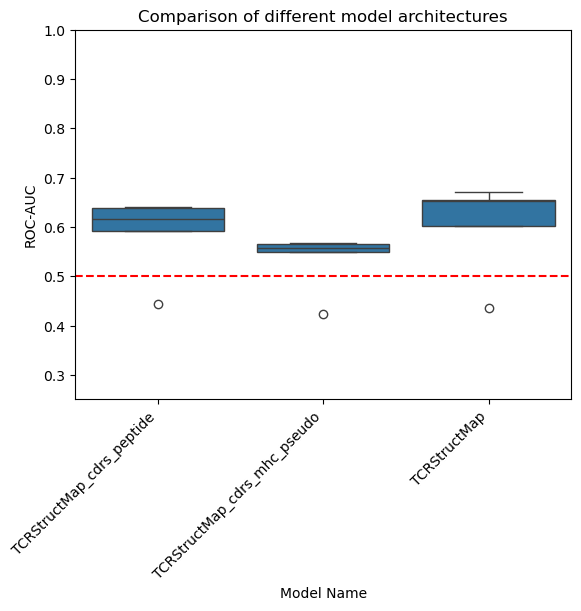

,mean,median,std
model_name,,,
TCRStructMap_cdrs_peptide,0.586127,0.616320,0.081990
TCRStructMap_cdrs_mhc_pseudo,0.533049,0.557731,0.061566
TCRStructMap,0.603445,0.652706,0.096951


In [7]:
plt.title('Comparison of different model architectures')

sns.boxplot(
    roc_results,
    x='model_name',
    y='roc_auc',
    order=sorted(roc_results['model_name'].unique(), reverse=True),
)
plt.axhline(0.5, color='r', linestyle='dashed')

plt.ylabel('ROC-AUC')
plt.xlabel('Model Name')
plt.xticks(rotation=45, ha='right')
plt.ylim([0.25, 1.0])
plt.show()

roc_results_agg = roc_results.groupby('model_name')['roc_auc'].agg(['mean', 'median', 'std'])
roc_results_agg = roc_results_agg.loc[sorted(roc_results_agg.index, reverse=True)]

roc_results_agg

In [8]:
pg.friedman(roc_results, dv='roc_auc', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.76,1.6,6.4,12.666667,0.007191


In [ ]:
groups = list(roc_results.set_index('fold').groupby('model_name')['roc_auc'])
groups = sorted(groups, reverse=True)
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap_cdrs_peptide,TCRStructMap_cdrs_mhc_pseudo,0.0,0.0625,False
1,TCRStructMap_cdrs_peptide,TCRStructMap,4.0,0.4375,False
2,TCRStructMap_cdrs_mhc_pseudo,TCRStructMap,0.0,0.0625,False


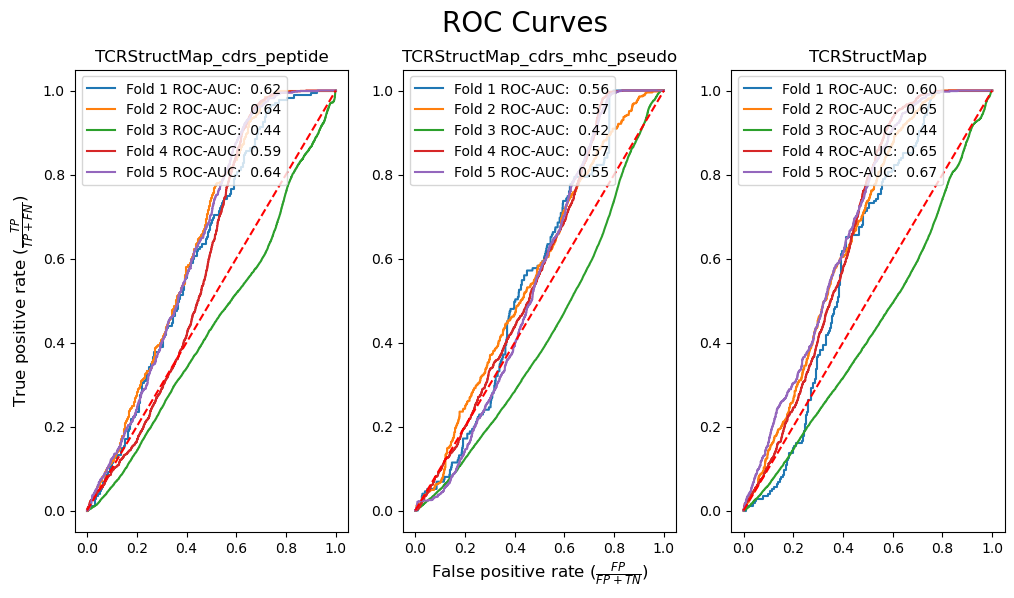

In [10]:
model_groups = roc_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), reverse=True)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('ROC Curves', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['roc_auc'].to_numpy()[0]
        group = fold_group.explode(['tpr', 'fpr'])

        axes[i].plot(group['fpr'], group['tpr'], label=f'Fold {fold} ROC-AUC: {roc_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)', fontsize=12)

    axes[i].set_title(model_name)

    axes[i].plot([0, 1], [0, 1], 'r--')
    axes[i].legend()

In [11]:
model_groups = roc_results.groupby('model_name')

fpr_interp = np.linspace(0, 1, 100)
tpr_interp = {}

for model_name, model_group in model_groups:
    tpr_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['tpr', 'fpr'])

        tpr_interp[model_name][fold] = np.interp(fpr_interp, group['fpr'].apply(float), group['tpr'].apply(float))

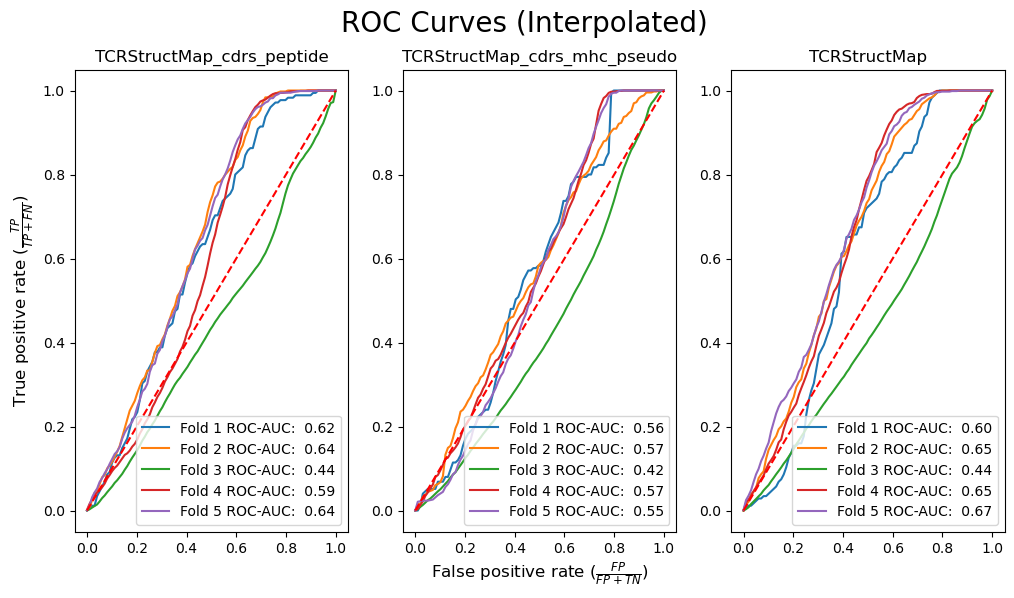

In [12]:
model_groups = roc_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), reverse=True)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('ROC Curves (Interpolated)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['roc_auc'].to_numpy()[0]

        axes[i].plot(fpr_interp, tpr_interp[model_name][fold], label=f'Fold {fold} ROC-AUC: {roc_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0, 1], 'r--')
    axes[i].legend()

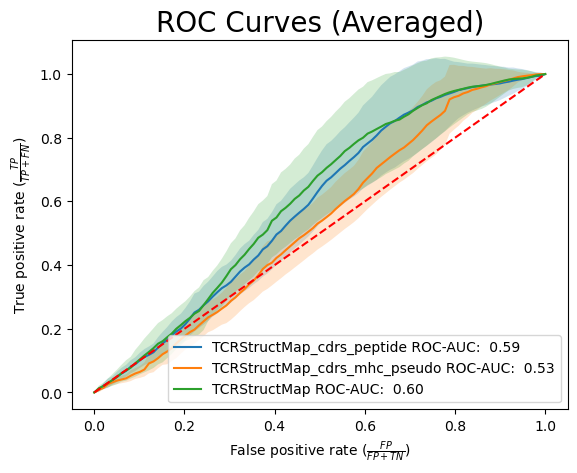

In [13]:
model_groups = roc_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), reverse=True)

for model_name in model_group_names:
    model_group = model_groups.get_group(model_name)

    tpr_mean = np.mean(np.array(list(tpr_interp[model_name].values())).T, axis=1)
    tpr_std = np.std(np.array(list(tpr_interp[model_name].values())).T, axis=1)

    roc_auc = metrics.auc(fpr_interp, tpr_mean)

    plt.plot(fpr_interp, tpr_mean, label=f'{model_name} ROC-AUC: {roc_auc: .2f}')
    plt.fill_between(fpr_interp, tpr_mean - tpr_std, tpr_mean + tpr_std, alpha=0.2)

plt.title('ROC Curves (Averaged)', fontsize=20)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)')
plt.ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)')
plt.legend()

plt.show()

## Precision-Recall

In [14]:
pr_results = predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.precision_recall_curve(group['label'], group['prediction']),
    include_groups=False,
)
pr_results.name = 'pr_curve'
pr_results = pr_results.reset_index()

In [15]:
pr_results[['precision', 'recall', 'threshold']] = pr_results['pr_curve'].apply(pd.Series)

In [16]:
pr_results['pr_auc'] = pr_results.apply(lambda row: metrics.auc(row['recall'], row['precision']), axis=1)

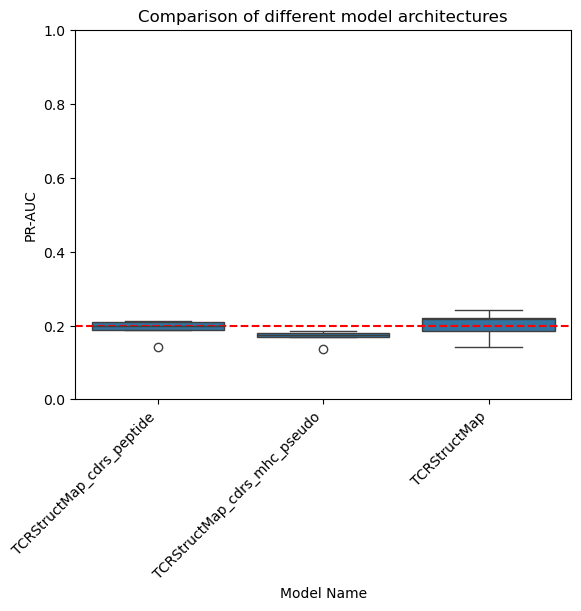

,mean,median,std
model_name,,,
TCRStructMap_cdrs_peptide,0.191086,0.199290,0.028440
TCRStructMap_cdrs_mhc_pseudo,0.168774,0.174134,0.018807
TCRStructMap,0.200914,0.218490,0.038677


In [17]:
sns.boxplot(pr_results, x='model_name', y='pr_auc', order=sorted(pr_results['model_name'], reverse=True))
plt.axhline(0.2, color='r', linestyle='dashed')

plt.title('Comparison of different model architectures')
plt.ylim([0.0, 1.0])
plt.xlabel('Model Name')
plt.ylabel('PR-AUC')
plt.xticks(rotation=45, ha='right')
plt.show()

pr_results_agg = pr_results.groupby('model_name')['pr_auc'].agg(['mean', 'median', 'std'])
pr_results_agg = pr_results_agg.loc[sorted(pr_results_agg.index, reverse=True)]
pr_results_agg

In [18]:
pg.friedman(pr_results, dv='pr_auc', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.76,1.6,6.4,12.666667,0.007191


In [19]:
groups = list(pr_results.set_index('fold').groupby('model_name')['pr_auc'])
groups = sorted(groups, reverse=True)
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap_cdrs_peptide,TCRStructMap_cdrs_mhc_pseudo,0.0,0.0625,False
1,TCRStructMap_cdrs_peptide,TCRStructMap,4.0,0.4375,False
2,TCRStructMap_cdrs_mhc_pseudo,TCRStructMap,0.0,0.0625,False


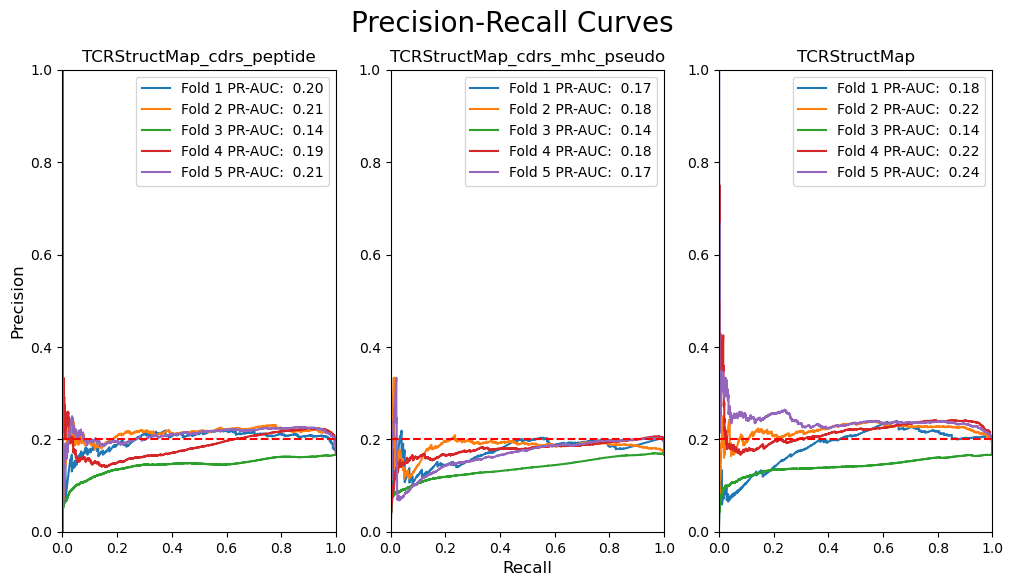

In [20]:
model_groups = pr_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), reverse=True)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]
        group = fold_group.explode(['recall', 'precision'])

        axes[i].plot(group['recall'], group['precision'], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [1 / 5, 1 / 5], 'r--')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])
    axes[i].legend()

In [21]:
model_groups = pr_results.groupby('model_name')

recall_interp = np.linspace(0, 1, 100)
precision_interp = {}

for model_name, model_group in model_groups:
    precision_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['recall', 'precision'])

        precision_interp[model_name][fold] = np.interp(
            recall_interp,
            group['recall'].apply(float)[::-1],
            group['precision'].apply(float)[::-1],
        )

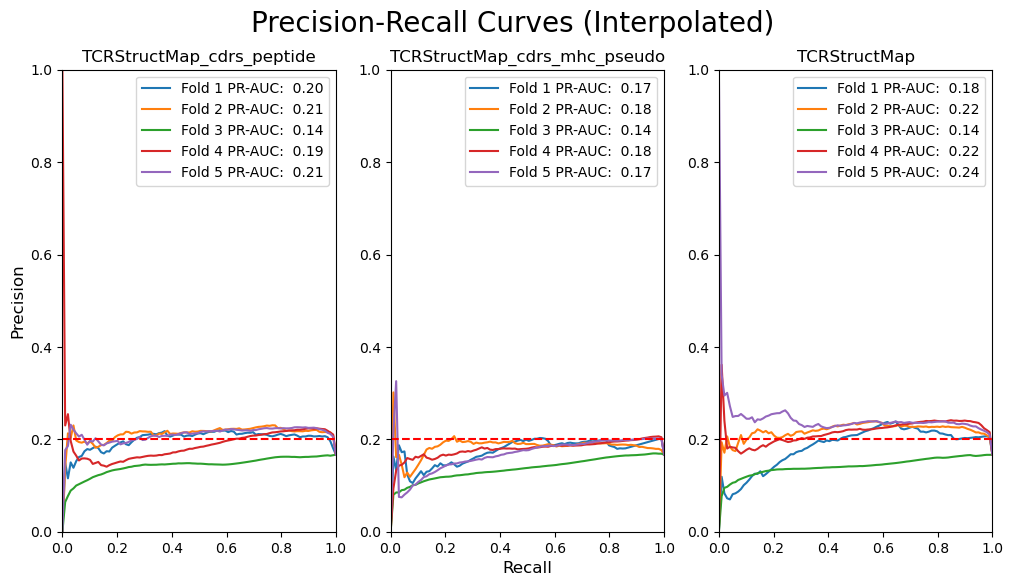

In [22]:
model_groups = pr_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), reverse=True)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves (Interpolated)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]

        axes[i].plot(recall_interp, precision_interp[model_name][fold], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [1 / 5, 1 / 5], 'r--')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])
    axes[i].legend()

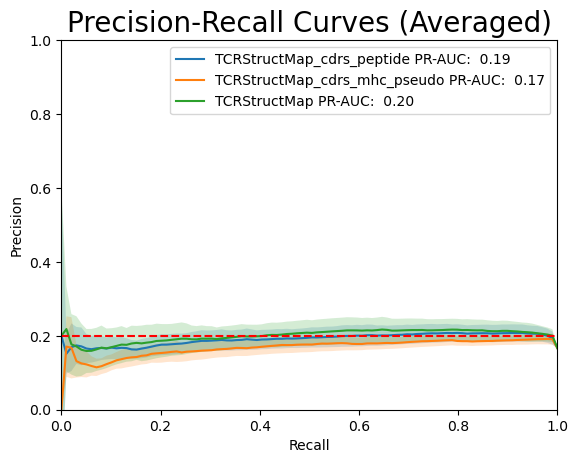

In [23]:
model_groups = pr_results.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), reverse=True)

for model_name in model_group_names:
    precision_mean = np.mean(np.array(list(precision_interp[model_name].values())).T, axis=1)
    precision_std = np.std(np.array(list(precision_interp[model_name].values())).T, axis=1)

    pr_auc = metrics.auc(recall_interp, precision_mean)

    plt.plot(recall_interp, precision_mean, label=f'{model_name} PR-AUC: {pr_auc: .2f}')
    plt.fill_between(recall_interp, precision_mean - precision_std, precision_mean + precision_std, alpha=0.2)

plt.title('Precision-Recall Curves (Averaged)', fontsize=20)
plt.plot([0, 1], [1 / 5, 1 / 5], 'r--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.legend()

plt.show()

### Balancing classes

In [24]:
def down_sample_group(group: pd.DataFrame, random_state: int | np.random.Generator | None = None) -> pd.DataFrame:
    positives = group[group['label'] == 1]
    negatives = group[group['label'] == 0]

    num_positives = len(positives)
    num_negatives = len(negatives)

    if num_positives > num_negatives:
        return pd.concat([positives.sample(num_negatives, random_state=random_state), negatives])

    if num_positives < num_negatives:
        return pd.concat([positives, negatives.sample(num_positives, random_state=random_state)])

    return group


rng = np.random.default_rng(123)
balanced_predictions = (
    predictions.groupby(['model_name', 'fold'])
    .apply(
        down_sample_group,
        random_state=rng,
        include_groups=False,
    )
    .reset_index()
)

In [25]:
pr_results_balanced = balanced_predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.precision_recall_curve(group['label'], group['prediction']),
    include_groups=False,
)
pr_results_balanced.name = 'pr_curve'
pr_results_balanced = pr_results_balanced.reset_index()

In [26]:
pr_results_balanced[['precision', 'recall', 'threshold']] = pr_results_balanced['pr_curve'].apply(pd.Series)

In [27]:
pr_results_balanced['pr_auc'] = pr_results_balanced.apply(
    lambda row: metrics.auc(row['recall'], row['precision']), axis=1
)

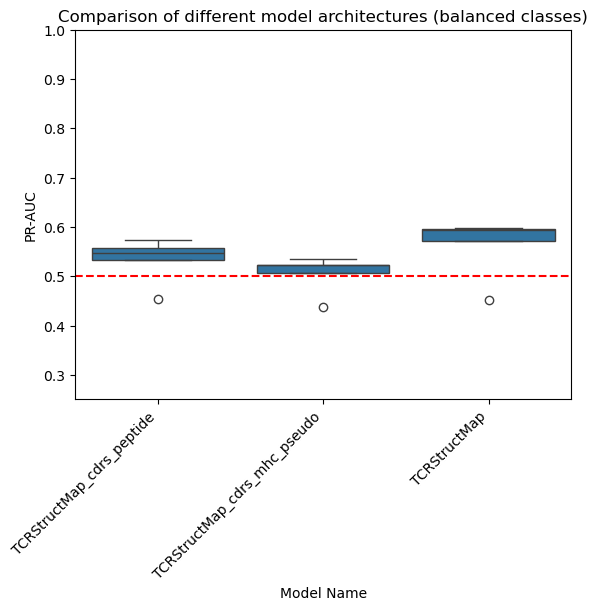

,mean,median,std
model_name,,,
TCRStructMap_cdrs_peptide,0.533032,0.547750,0.046505
TCRStructMap_cdrs_mhc_pseudo,0.504759,0.522282,0.038727
TCRStructMap,0.562168,0.594651,0.062898


In [28]:
sns.boxplot(
    pr_results_balanced,
    x='model_name',
    y='pr_auc',
    order=sorted(pr_results_balanced['model_name'].unique(), reverse=True),
)
plt.axhline(0.5, color='r', linestyle='dashed')

plt.title('Comparison of different model architectures (balanced classes)')
plt.xlabel('Model Name')
plt.ylabel('PR-AUC')
plt.xticks(rotation=45, ha='right')
plt.ylim([0.25, 1.0])
plt.show()

pr_results_balanced_agg = pr_results_balanced.groupby('model_name')['pr_auc'].agg(['mean', 'median', 'std'])
pr_results_balanced_agg = pr_results_balanced_agg.loc[sorted(pr_results_balanced_agg.index, reverse=True)]
pr_results_balanced_agg

In [29]:
pg.friedman(pr_results_balanced, dv='pr_auc', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.84,1.6,6.4,21.0,0.001936


In [30]:
groups = list(pr_results_balanced.set_index('fold').groupby('model_name')['pr_auc'])
groups = sorted(groups, reverse=True)
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap_cdrs_peptide,TCRStructMap_cdrs_mhc_pseudo,0.0,0.0625,False
1,TCRStructMap_cdrs_peptide,TCRStructMap,1.0,0.1250,False
2,TCRStructMap_cdrs_mhc_pseudo,TCRStructMap,0.0,0.0625,False


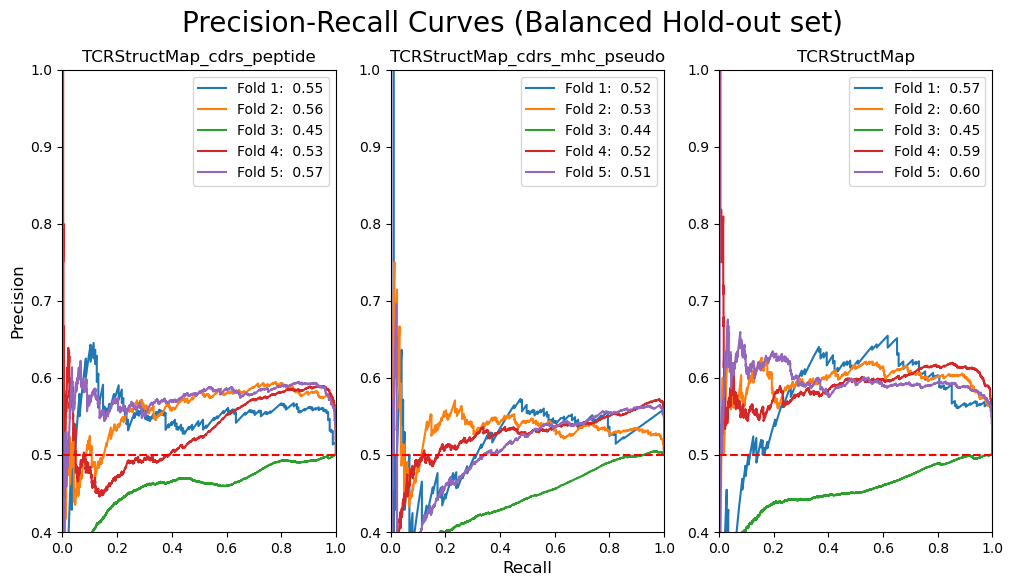

In [31]:
model_groups = pr_results_balanced.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), reverse=True)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves (Balanced Hold-out set)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['pr_auc'].to_numpy()[0]
        group = fold_group.explode(['recall', 'precision'])

        axes[i].plot(group['recall'], group['precision'], label=f'Fold {fold}: {roc_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0.5, 0.5], 'r--')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0.4, 1])
    axes[i].legend()

In [32]:
model_groups = pr_results_balanced.groupby('model_name')

recall_interp = np.linspace(0, 1, 100)
precision_interp = {}

for model_name, model_group in model_groups:
    precision_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['recall', 'precision'])

        precision_interp[model_name][fold] = np.interp(
            recall_interp,
            group['recall'].apply(float)[::-1],
            group['precision'].apply(float)[::-1],
        )

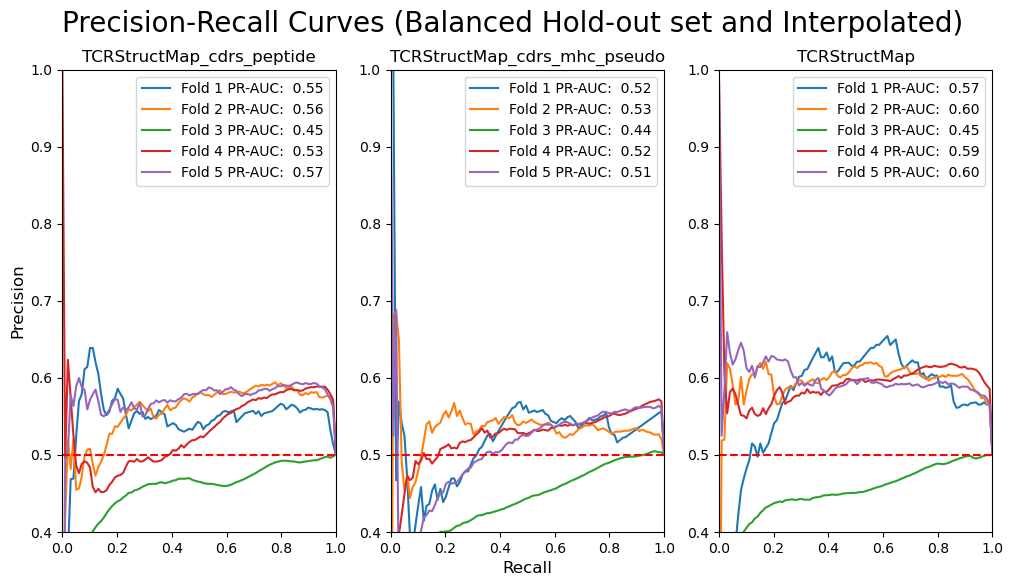

In [33]:
model_groups = pr_results_balanced.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), reverse=True)

fig, axes = plt.subplots(1, len(model_groups), figsize=(12, 6))

fig.suptitle('Precision-Recall Curves (Balanced Hold-out set and Interpolated)', fontsize=20)

for i, model_name in enumerate(model_group_names):
    model_group = model_groups.get_group(model_name)

    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]

        axes[i].plot(recall_interp, precision_interp[model_name][fold], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    if i == 0:
        axes[i].set_ylabel('Precision', fontsize=12)

    if i == len(model_groups) // 2:
        axes[i].set_xlabel('Recall', fontsize=12)

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0.5, 0.5], 'r--')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0.4, 1])
    axes[i].legend()

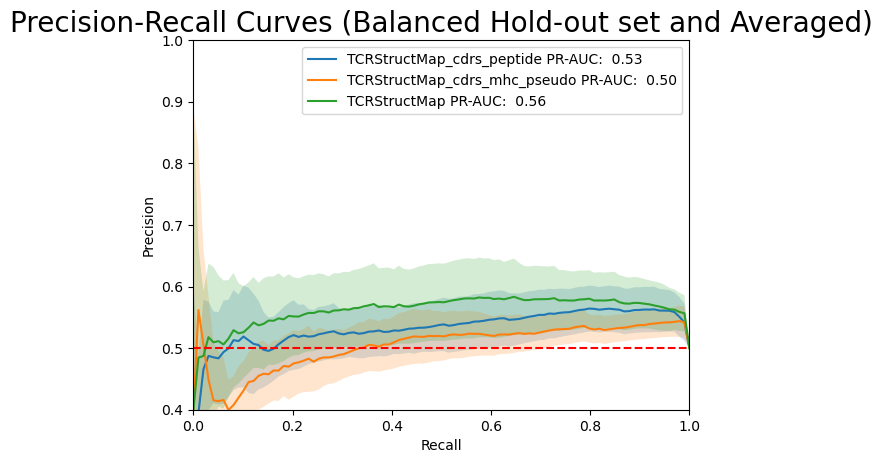

In [34]:
model_groups = pr_results_balanced.groupby('model_name')
model_group_names = sorted(model_groups.groups.keys(), reverse=True)

for model_name in model_group_names:
    precision_mean = np.mean(np.array(list(precision_interp[model_name].values())).T, axis=1)
    precision_std = np.std(np.array(list(precision_interp[model_name].values())).T, axis=1)

    pr_auc = metrics.auc(recall_interp, precision_mean)

    plt.plot(recall_interp, precision_mean, label=f'{model_name} PR-AUC: {pr_auc: .2f}')
    plt.fill_between(recall_interp, precision_mean - precision_std, precision_mean + precision_std, alpha=0.2)

plt.title('Precision-Recall Curves (Balanced Hold-out set and Averaged)', fontsize=20)
plt.plot([0, 1], [0.5, 0.5], 'r--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0, 1])
plt.ylim([0.4, 1])
plt.legend()

plt.show()

## F1-Score

In [35]:
THRESHOLD = 0.5
predictions['prediction_binary'] = (predictions['prediction'] > THRESHOLD).apply(int)

In [36]:
f1_results = predictions.groupby(['model_name', 'fold']).apply(
    lambda row: metrics.f1_score(row['label'], row['prediction_binary']),
    include_groups=False,
)
f1_results.name = 'f1_score'
f1_results = f1_results.reset_index()

f1_results_table = f1_results.pivot_table(index='fold', columns='model_name', values='f1_score')
f1_results_table = f1_results_table[sorted(f1_results_table.columns, reverse=True)]
f1_results_table

model_name,TCRStructMap_cdrs_peptide,TCRStructMap_cdrs_mhc_pseudo,TCRStructMap
fold,,,
1,0.010811,0.000000,0.000000
2,0.004494,0.000000,0.030501
3,0.009268,0.026096,0.011831
4,0.014545,0.007111,0.051738
5,0.002561,0.002591,0.002608


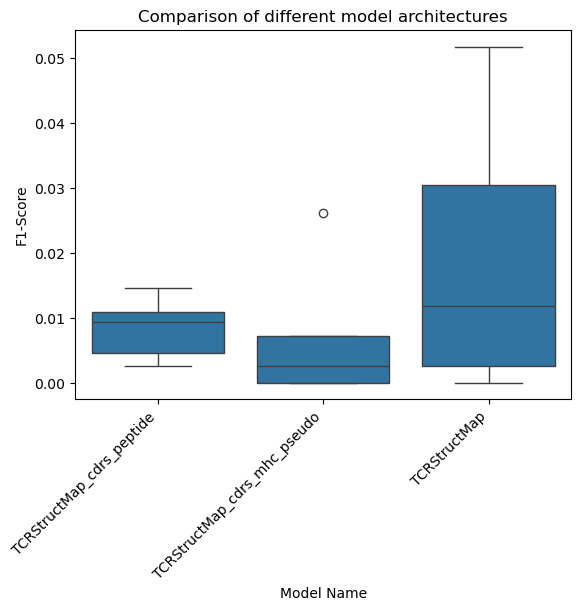

,mean,median,std
model_name,,,
TCRStructMap_cdrs_peptide,0.008336,0.009268,0.004839
TCRStructMap_cdrs_mhc_pseudo,0.007160,0.002591,0.010977
TCRStructMap,0.019336,0.011831,0.021706


In [37]:
sns.boxplot(
    f1_results,
    x='model_name',
    y='f1_score',
    order=sorted(f1_results['model_name'].unique(), reverse=True),
)

plt.title('Comparison of different model architectures')
plt.xlabel('Model Name')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.show()

f1_results_agg = f1_results.groupby('model_name')['f1_score'].agg(['mean', 'median', 'std'])
f1_results_agg = f1_results_agg.loc[sorted(f1_results_agg.index, reverse=True)]
f1_results_agg

In [38]:
pg.friedman(f1_results, dv='f1_score', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.2,1.6,6.4,1.0,0.399098


In [39]:
groups = list(f1_results.set_index('fold').groupby('model_name')['f1_score'])
groups = sorted(groups, reverse=True)
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap_cdrs_peptide,TCRStructMap_cdrs_mhc_pseudo,6.0,0.8125,False
1,TCRStructMap_cdrs_peptide,TCRStructMap,3.0,0.3125,False
2,TCRStructMap_cdrs_mhc_pseudo,TCRStructMap,2.0,0.3750,False


### Balancing classes

In [40]:
balanced_predictions['prediction_binary'] = (balanced_predictions['prediction'] > THRESHOLD).apply(int)

In [41]:
f1_results_balanced = balanced_predictions.groupby(['model_name', 'fold']).apply(
    lambda row: metrics.f1_score(row['label'], row['prediction_binary']),
    include_groups=False,
)
f1_results_balanced.name = 'f1_score'
f1_results_balanced = f1_results_balanced.reset_index()

f1_results_balanced_table = f1_results_balanced.pivot_table(index='fold', columns='model_name', values='f1_score')
f1_results_balanced_table = f1_results_balanced_table[sorted(f1_results_balanced_table.columns, reverse=True)]
f1_results_balanced_table

model_name,TCRStructMap_cdrs_peptide,TCRStructMap_cdrs_mhc_pseudo,TCRStructMap
fold,,,
1,0.011111,0.000000,0.000000
2,0.004608,0.000000,0.031746
3,0.009862,0.029458,0.012562
4,0.014787,0.007401,0.056990
5,0.002597,0.002608,0.002608


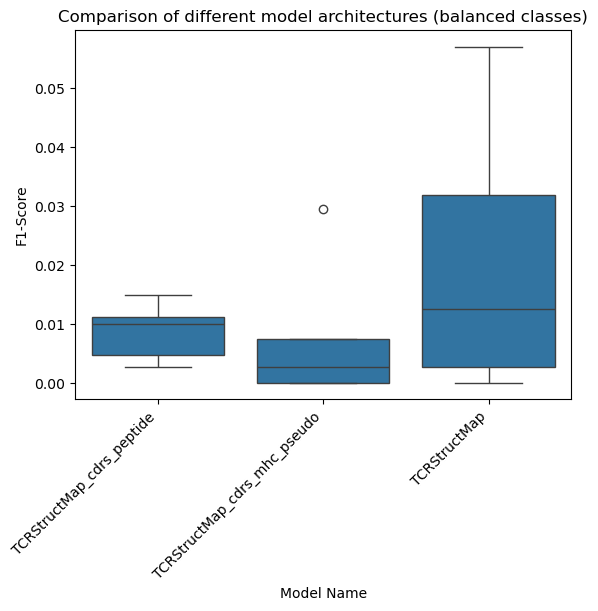

,mean,median,std
model_name,,,
TCRStructMap_cdrs_peptide,0.008593,0.009862,0.004953
TCRStructMap_cdrs_mhc_pseudo,0.007893,0.002608,0.012428
TCRStructMap,0.020781,0.012562,0.023775


In [42]:
sns.boxplot(
    f1_results_balanced,
    x='model_name',
    y='f1_score',
    order=sorted(f1_results_balanced['model_name'].unique(), reverse=True),
)

plt.title('Comparison of different model architectures (balanced classes)')
plt.xlabel('Model Name')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.show()

f1_results_balanced_agg = f1_results_balanced.groupby('model_name')['f1_score'].agg(['mean', 'median', 'std'])
f1_results_balanced_agg = f1_results_balanced_agg.loc[sorted(f1_results_balanced_agg.index, reverse=True)]
f1_results_balanced_agg

In [ ]:
pg.friedman(f1_results_balanced, dv='f1_score', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.133333,1.6,6.4,0.615385,0.535383


In [44]:
groups = list(f1_results_balanced.set_index('fold').groupby('model_name')['f1_score'])
groups = sorted(groups, reverse=True)
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap_cdrs_peptide,TCRStructMap_cdrs_mhc_pseudo,6.0,0.8125,False
1,TCRStructMap_cdrs_peptide,TCRStructMap,3.0,0.3125,False
2,TCRStructMap_cdrs_mhc_pseudo,TCRStructMap,1.0,0.5000,False


## Comparison of prediction results to mimimum distance between the peptides and the training set

In [45]:
with open('data/interim/peptides.txt') as fh:
    peptide_key = np.array(fh.read().rstrip().split('\n'))

peptide_distances = np.loadtxt('data/interim/peptide_distances.txt', dtype=int)

In [46]:
def get_minimum_peptide_distance(peptide_sequence: str, training_peptides: np.ndarray) -> int:
    if peptide_sequence not in peptide_key:
        return np.nan

    training_key_idxs = np.where(np.isin(peptide_key, training_peptides))[0]
    peptide_index = np.where(peptide_sequence == peptide_key)[0][0]

    return np.min(peptide_distances[peptide_index][training_key_idxs])

In [47]:
peptide_folds = predictions[['peptide', 'fold']].drop_duplicates()
peptide_folds['min_peptide_distance'] = peptide_folds.apply(
    lambda row: get_minimum_peptide_distance(row.peptide, sequences[sequences['fold'] != row.fold]['peptide'].unique()),
    axis=1,
)

In [48]:
predictions = predictions.merge(peptide_folds, how='left', on=['peptide', 'fold'])

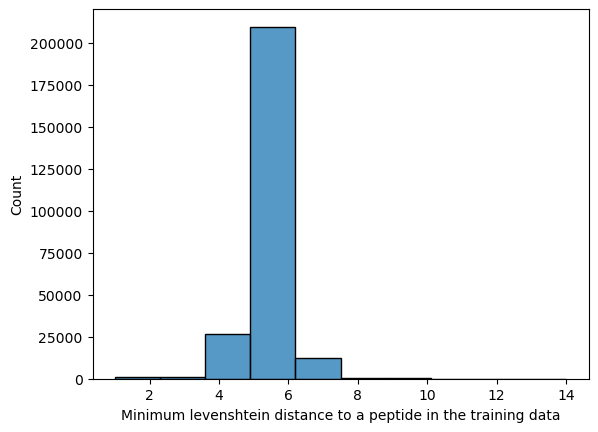

In [49]:
sns.histplot(predictions, x='min_peptide_distance', bins=10)

plt.xlabel('Minimum levenshtein distance to a peptide in the training data')
plt.show()

In [50]:
peptide_distance_roc_aucs = predictions.groupby(['model_name', 'fold', 'min_peptide_distance']).apply(
    lambda group: metrics.roc_auc_score(group['label'], group['prediction']),
    include_groups=False,
)
peptide_distance_roc_aucs.name = 'roc_auc'

peptide_distance_roc_aucs = peptide_distance_roc_aucs.reset_index()

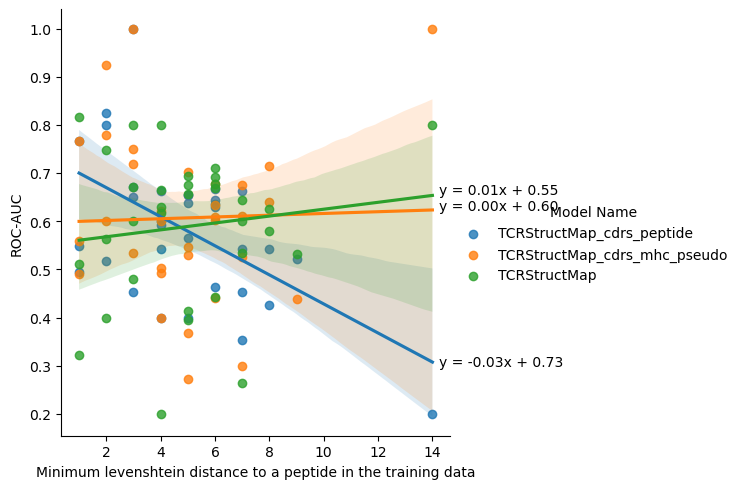

In [51]:
ax = sns.lmplot(
    peptide_distance_roc_aucs,
    x='min_peptide_distance',
    y='roc_auc',
    hue='model_name',
    hue_order=sorted(peptide_distance_roc_aucs['model_name'].unique(), reverse=True),
)

for model_name in peptide_distance_roc_aucs['model_name'].unique():
    subset = peptide_distance_roc_aucs[peptide_distance_roc_aucs['model_name'] == model_name]
    slope, intercept, r_value, p_value, std_err = stats.linregress(subset['min_peptide_distance'], subset['roc_auc'])

    equation = f'y = {slope:.2f}x + {intercept:.2f}'

    x_pos = subset['min_peptide_distance'].max() + 0.25
    y_pos = slope * x_pos + intercept

    plt.text(x_pos, y_pos, equation, color='black')

ax.legend.set_title('Model Name')
plt.xlabel('Minimum levenshtein distance to a peptide in the training data')
plt.ylabel('ROC-AUC')

plt.show()

In [ ]:
peptide_distance_roc_aucs_lines = peptide_distance_roc_aucs.groupby(['model_name', 'fold']).apply(
    lambda group: stats.linregress(group['min_peptide_distance'], group['roc_auc']),
    include_groups=False,
)

peptide_distance_roc_aucs_lines.name = 'line'
peptide_distance_roc_aucs_lines = peptide_distance_roc_aucs_lines.reset_index()

peptide_distance_roc_aucs_lines[['slope', 'intercept', 'r_value', 'p_value', 'std_err']] = (
    peptide_distance_roc_aucs_lines['line'].apply(pd.Series)
)

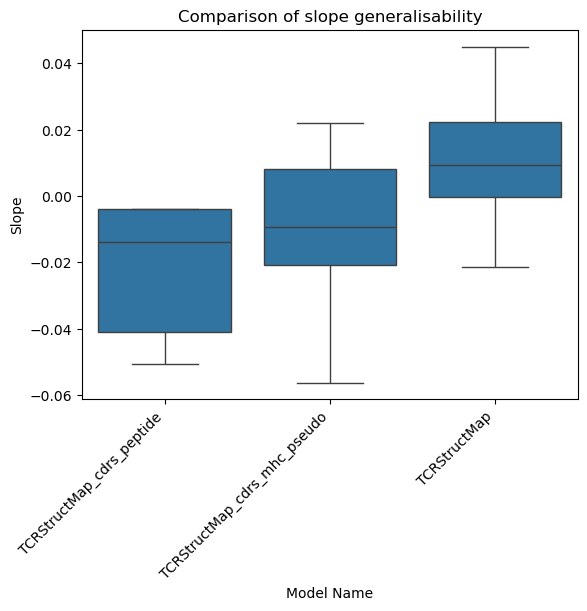

,mean,median,std
model_name,,,
TCRStructMap_cdrs_peptide,-0.022713,-0.013862,0.021791
TCRStructMap_cdrs_mhc_pseudo,-0.011240,-0.009352,0.030029
TCRStructMap,0.010962,0.009243,0.024860


In [53]:
sns.boxplot(
    peptide_distance_roc_aucs_lines,
    x='model_name',
    y='slope',
    order=sorted(peptide_distance_roc_aucs_lines['model_name'].unique(), reverse=True),
)

plt.title('Comparison of slope generalisability')
plt.ylabel('Slope')
plt.xlabel('Model Name')
plt.xticks(rotation=45, ha='right')
plt.show()

peptide_distance_roc_aucs_lines_agg = peptide_distance_roc_aucs_lines.groupby('model_name')['slope'].agg(
    ['mean', 'median', 'std'],
)
peptide_distance_roc_aucs_lines_agg = peptide_distance_roc_aucs_lines_agg.loc[
    sorted(peptide_distance_roc_aucs_lines_agg.index, reverse=True)
]
peptide_distance_roc_aucs_lines_agg

In [54]:
pg.friedman(peptide_distance_roc_aucs_lines, dv='slope', within='model_name', subject='fold', method='f')

,Source,W,ddof1,ddof2,F,p-unc
Friedman,model_name,0.16,1.6,6.4,0.761905,0.47663


In [55]:
groups = list(peptide_distance_roc_aucs_lines.set_index('fold').groupby('model_name')['slope'])
groups = sorted(groups, reverse=True)
groups = [(group_name, group.sort_index()) for group_name, group in groups]

significance_level = 0.05 / len(groups)

results = collections.defaultdict(list)
for (group1_name, group1), (group2_name, group2) in itertools.combinations(groups, 2):
    stat, p_val = stats.wilcoxon(group1, group2)

    results['group1'].append(group1_name)
    results['group2'].append(group2_name)
    results['stat'].append(stat)
    results['p_val'].append(p_val)
    results['signficant'].append(p_val < significance_level)

pd.DataFrame(results)

,group1,group2,stat,p_val,signficant
0,TCRStructMap_cdrs_peptide,TCRStructMap_cdrs_mhc_pseudo,5.0,0.625,False
1,TCRStructMap_cdrs_peptide,TCRStructMap,1.0,0.125,False
2,TCRStructMap_cdrs_mhc_pseudo,TCRStructMap,5.0,0.625,False
